### Assignment 4 Q2

DONE: parts (a), (b), (c); TODO: rest

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, average_precision_score, recall_score, f1_score, balanced_accuracy_score
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
train_df = pd.read_excel('knn_imbalanced_dataset_Q2.xlsx', sheet_name='Train')
test_df = pd.read_excel('knn_imbalanced_dataset_Q2.xlsx', sheet_name='Test')

In [3]:
Xtrain, ytrain = train_df[['Temperature_C', 'Pressure_bar', 'Vibration_mm_s', 'Current_A', 'Acoustic_dB']], train_df['Class']
ytrain = ytrain.apply(['Normal', 'Fault'].index)    # convert to 0,1 class index
train_means, train_stds = Xtrain.mean(), Xtrain.std()
Xtrain = (Xtrain - train_means) / train_stds    # z-standardize (0 mean, 1 variance) all features

Xtest, ytest = test_df[['Temperature_C', 'Pressure_bar', 'Vibration_mm_s', 'Current_A', 'Acoustic_dB']], test_df['Class']
ytest = ytest.apply(['Normal', 'Fault'].index)    # convert to 0,1 class index
Xtest = (Xtest - train_means) / train_stds  

In [ ]:
folds = 10
k_errors = []     # cross-validation errors for each k
for k in range(2,11):
    model = KNeighborsClassifier(n_neighbors=k)    # NOTE: KNeigbhorsClassifier used for supervised (classify), NearestNeighbors used for unsupervised
    fold_accuracies = cross_val_score(model, Xtrain, ytrain, cv=folds, scoring='accuracy')
    k_errors.append(1 - sum(fold_accuracies) / folds)

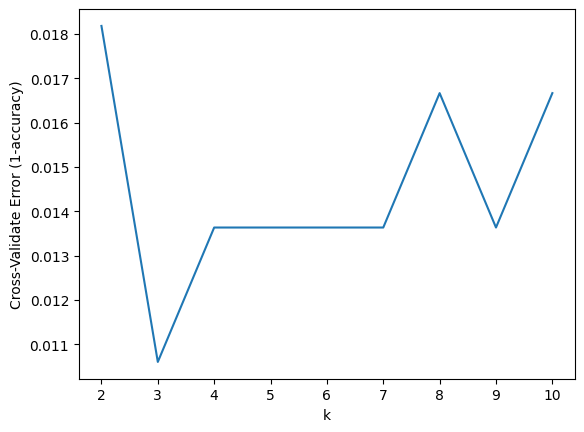

In [5]:
# KNN Error Plot
plt.plot(np.arange(2,11), k_errors)
plt.xlabel('k')
plt.ylabel('Cross-Validate Error (1-accuracy)')
plt.show()

In [9]:
best_k = 3     # lowest cross-validation error in above plot
model = KNeighborsClassifier(best_k).fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

Accuracy: 97.14%
Avg Precision: 82.86%
Avg Recall: 80.00%
F1 Score: 88.89%
Balanced Accuracy: 90.00%


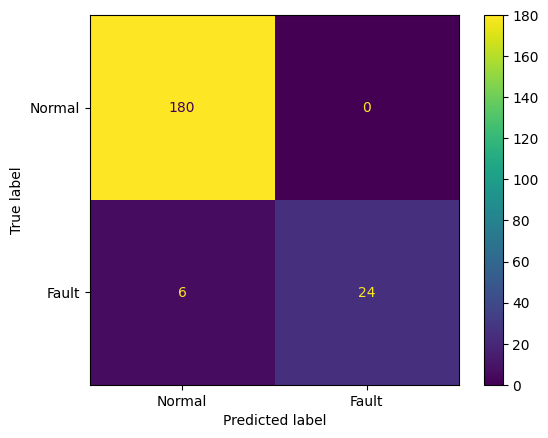

In [ ]:
# Metrics
print(f'Accuracy: {accuracy_score(ytest, ypred) :.2%}')
print(f'Avg Precision: {average_precision_score(ytest, ypred) :.2%}')
print(f'Avg Recall: {recall_score(ytest, ypred) :.2%}')
print(f'F1 Score: {f1_score(ytest, ypred) :.2%}')
print(f'Balanced Accuracy: {balanced_accuracy_score(ytest, ypred) :.2%}')

# Confusion Matrix
cm_np = confusion_matrix(ytest, ypred)
_ = ConfusionMatrixDisplay(cm_np, display_labels=['Normal', 'Fault']).plot()
plt.show()

In [ ]:
# Training data has 600 Normal (0), 60 Fault (1) rows

# oversample minority class (Fault)
Xtrain_over = pd.concat([Xtrain[ytrain == 0], Xtrain[ytrain == 1].sample(600, replace=True)]) 
ytrain_over = pd.Series([0]*600 + [1]*600)

# undersample majority class (Normal)
# Xtrain_under = pd.concat([Xtrain[ytrain == 0].sample(60), Xtrain[ytrain == 1]])
# ytrain_under = pd.Series([[0]*60 + [1]*60])

Accuracy: 96.67%
Avg Precision: 79.61%
Avg Recall: 86.67%
F1 Score: 88.14%
Balanced Accuracy: 92.50%


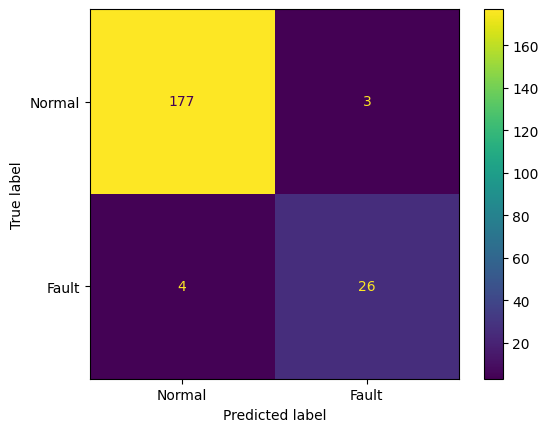

In [22]:
# retrain keeping in mind imbalanced data using over-sampling + weighted KNN
model = KNeighborsClassifier(best_k, weights='distance').fit(Xtrain_over, ytrain_over)      # Weighted KNN: weigh by inverse of distance
ypred = model.predict(Xtest)

# Metrics
print(f'Accuracy: {accuracy_score(ytest, ypred) :.2%}')
print(f'Avg Precision: {average_precision_score(ytest, ypred) :.2%}')
print(f'Avg Recall: {recall_score(ytest, ypred) :.2%}')
print(f'F1 Score: {f1_score(ytest, ypred) :.2%}')
print(f'Balanced Accuracy: {balanced_accuracy_score(ytest, ypred) :.2%}')

# Confusion Matrix
cm_np = confusion_matrix(ytest, ypred)
_ = ConfusionMatrixDisplay(cm_np, display_labels=['Normal', 'Fault']).plot()
plt.show()

New model (with over-sampled training data & weighted KNN) improved predictions a bit for minority class (Fault) - true predictions of class Fault increased (24 -> 26) at the expense of some decline in true predictions of class Normal (180 -> 177). Balanced Accuracy increased (90% to 92.5%).